In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns  # only used for the heatmap
# commit 2 imports:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
def load_and_clean_data(filepath):
    """
    Loads the CSV, prints a basic overview, drops duplicates,
    removes free books and price outliers via IQR.

    """
    df = pd.read_csv(filepath)

    print(f"Shape: {df.shape}")
    print(f"\nColumn types:\n{df.dtypes}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    initial_rows = len(df)
    df.drop_duplicates(inplace=True)

    # free books would break the ML prediction system
    df = df[df["Price"] > 0]

    # IQR method: remove statistically extreme price values
    Q1 = df["Price"].quantile(0.25)
    Q3 = df["Price"].quantile(0.75)
    IQR = Q3 - Q1
    # if it is cheaper than Q1 - (1.5 * IQR) or more expensive than Q3 + (1.5 * IQR), it is an extreme value, should be eliminated
    df = df[(df["Price"] >= Q1 - 1.5 * IQR) & (df["Price"] <= Q3 + 1.5 * IQR)]

    print(f"\nRows removed during cleaning: {initial_rows - len(df)}")
    print(f"Final shape: {df.shape}")
    return df


df_clean = load_and_clean_data("bestsellers.csv")
display(df_clean.head()) # example values

Shape: (600, 7)

Column types:
Name            object
Author          object
User Rating    float64
Reviews          int64
Price            int64
Year             int64
Genre           object
dtype: object

Missing values:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

Rows removed during cleaning: 43
Final shape: (557, 7)


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [72]:
def split_data(df, test_size=0.2, random_state=42):
    """
    Splits the data into a training set (80%) and a test set (20%).
    """
    df_train, df_test = train_test_split(df, test_size=test_size,
                                         random_state=random_state)
    print(f"Training set : {df_train.shape[0]} rows ({1 - test_size:.0%})")
    print(f"Test set     : {df_test.shape[0]} rows ({test_size:.0%})")
    print("\nAll EDA and analysis below is performed on the training set only.")
    return df_train, df_test

In [73]:
def apply_inflation_adjustment(df):
    """
    Adjusts book prices to their 2019 USD equivalent using multipliers.
    The Price column is overwritten so that all EDA plots and ML models automatically use comparable values.
    EDA and feature engineering will only be performed on the training set
    to avoid any information from the test set leaking into the model
    """
    df = df.copy()
    inflation_multipliers = {
        2009: 1.19, 2010: 1.17, 2011: 1.14, 2012: 1.11, 2013: 1.10,
        2014: 1.08, 2015: 1.08, 2016: 1.06, 2017: 1.04, 2018: 1.02, 2019: 1.00, 2020: 0.99
    }
    df["Price"] = (df["Price"] * df["Year"].map(inflation_multipliers)).round(2)
    return df

# apply to df_clean (original prices), then re-split, so re-running the cell doesn't chage prive
df_clean_adj      = apply_inflation_adjustment(df_clean)
df_train, df_test = split_data(df_clean_adj)

print("Price column now holds 2019-equivalent values.")
print(f"Mean adjusted price (training set): ${df_train['Price'].mean():.2f}")

Training set : 445 rows (80%)
Test set     : 112 rows (20%)

All EDA and analysis below is performed on the training set only.
Price column now holds 2019-equivalent values.
Mean adjusted price (training set): $12.65


In [74]:
def engineer_features(df):
    """
    Adds new columns needed for ML prediction, added to the training set.
    New columns:
        Genre_encoded (int): 1 = Fiction, 0 = Non Fiction
        Title_length  (int): number of characters in the book title
        Reviews_log   (float): log1p-transformed review count. Log is needed, so books with fewer reviews (~1000 reviews)
        can be compared with books with more reviews (~100,000 reviews)
    """
    df = df.copy()
    df["Genre_encoded"] = (df["Genre"] == "Fiction").astype(int)
    df["Reviews_log"]   = np.log1p(df["Reviews"]) # ln(1+x) is used, so if we have a book with zero reviews, the code does not crash
    df["Title_length"]  = df["Name"].apply(len)
    return df


df_train = engineer_features(df_train)
display(df_train[["Name", "Genre_encoded", "Reviews", "Reviews_log",
                   "Title_length", "Price"]].head(8)) # example values

,Name,Genre_encoded,Reviews,Reviews_log,Title_length,Price
195,Killers of the Flower Moon: The Osage Murders ...,0,8393,9.035272,70,17.68
95,Eclipse (Twilight Sagas),1,5505,8.613594,24,8.33
198,Killing Lincoln: The Shocking Assassination th...,0,9342,9.142383,105,11.40
160,Have a Little Faith: A True Story,0,1930,7.565793,33,4.76
217,Life,0,2752,7.920447,4,21.06
593,The Big Book of Silly Jokes for Kids,1,11668,9.364691,36,8.91
165,Homebody: A Guide to Creating Spaces You Never...,0,3776,8.236685,60,22.44
301,Steve Jobs,0,7827,8.965462,10,22.80


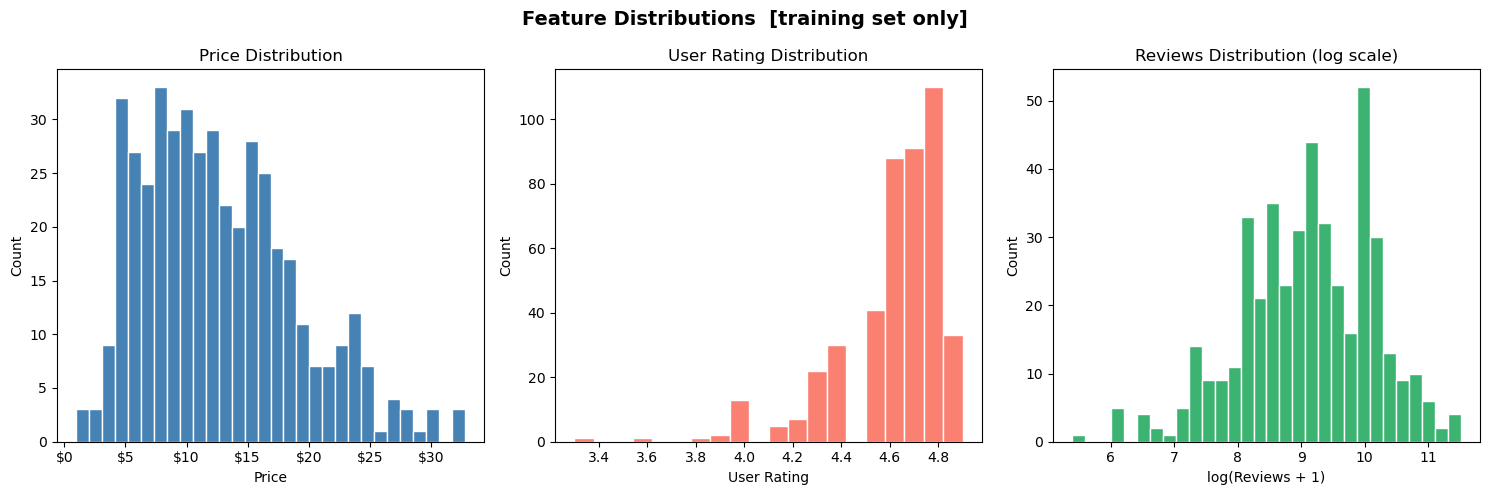

In [75]:
def plot_distributions(df):
    """
    Plots histograms for price, user rating, and log-transformed reviews.

    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Feature Distributions  [training set only]",
                 fontsize=14, fontweight="bold")

    axes[0].hist(df["Price"], bins=30, color="steelblue", edgecolor="white")
    axes[0].set_title("Price Distribution")
    axes[0].set_xlabel("Price")
    axes[0].set_ylabel("Count")
    axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:.0f}"))

    axes[1].hist(df["User Rating"], bins=20, color="salmon", edgecolor="white")
    axes[1].set_title("User Rating Distribution")
    axes[1].set_xlabel("User Rating")
    axes[1].set_ylabel("Count")

    axes[2].hist(df["Reviews_log"], bins=30, color="mediumseagreen", edgecolor="white")
    axes[2].set_title("Reviews Distribution (log scale)")
    axes[2].set_xlabel("log(Reviews + 1)")
    axes[2].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig("distributions.png", dpi=150)
    plt.show()


# We check distributions to decide if transformations are needed before modeling
plot_distributions(df_train)

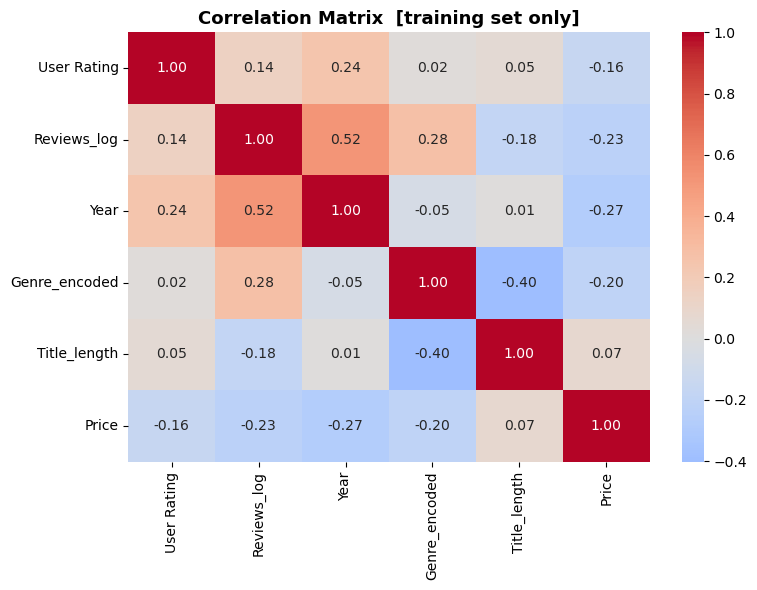


Correlation with Price (sorted):
Title_length     0.072171
User Rating     -0.160404
Genre_encoded   -0.204685
Reviews_log     -0.227848
Year            -0.271589
Name: Price, dtype: float64


In [76]:
def plot_correlation_heatmap(df):
    """
    Plots a correlation heatmap between all numeric features.
    Shows which features are mathematically related to price.
    If none of the variables show a strong linear correlation, we can say that book price prediction is non-linear,
    hence the random forest prediction model might be more suitable than the linear regression.
    """
    numeric_cols = ["User Rating", "Reviews_log", "Year",
                    "Genre_encoded", "Title_length", "Price"]
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation Matrix  [training set only]",
              fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", dpi=150)
    plt.show()

    print("\nCorrelation with Price (sorted):")
    print(corr["Price"].drop("Price").sort_values(ascending=False))

plot_correlation_heatmap(df_train)

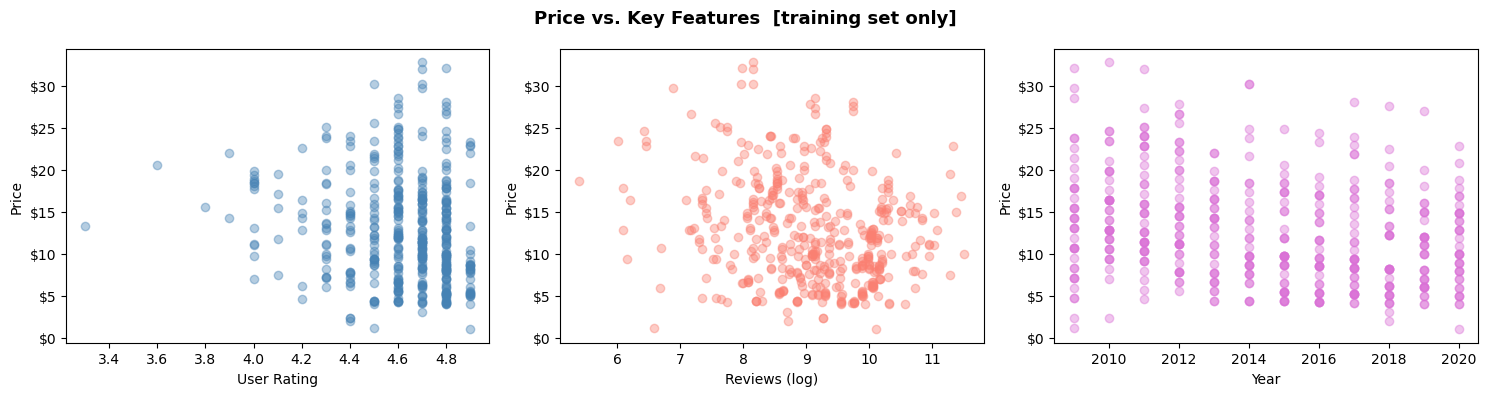

,Count,Mean,Std Deviation,Minimum,25% (Q1),50% (Median),75% (Q3),Maximum
Fiction,185.0,11.13,5.6,0.99,7.42,9.72,14.28,29.75
Non Fiction,260.0,13.73,6.5,1.19,8.60,12.96,17.85,32.76


In [77]:
def plot_price_relationships(df):
    """
    We do plots of price vs. user rating, reviews, and year,
    plus a table comparing fiction vs. non-fiction pricing and some stastical tools.
    Again, if the plots are noisy and the pricing mechanism is non-linear, a random forest model is more suitable for us.

    """
    dollar_fmt = ticker.FuncFormatter(lambda x, _: f"${x:.0f}") #the prices are in US dollar

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Price vs. Key Features  [training set only]",
                 fontsize=13, fontweight="bold")

    axes[0].scatter(df["User Rating"], df["Price"], alpha=0.4, color="steelblue")
    axes[0].set_xlabel("User Rating")
    axes[0].set_ylabel("Price")
    axes[0].yaxis.set_major_formatter(dollar_fmt)

    axes[1].scatter(df["Reviews_log"], df["Price"], alpha=0.4, color="salmon")
    axes[1].set_xlabel("Reviews (log)")
    axes[1].set_ylabel("Price")
    axes[1].yaxis.set_major_formatter(dollar_fmt)

    axes[2].scatter(df["Year"], df["Price"], alpha=0.4, color="orchid")
    axes[2].set_xlabel("Year")
    axes[2].set_ylabel("Price")
    axes[2].yaxis.set_major_formatter(dollar_fmt)

    plt.tight_layout()
    plt.savefig("scatter_price.png", dpi=150)
    plt.show()

    prices_fiction    = df[df["Genre"] == "Fiction"]["Price"]
    prices_nonfiction = df[df["Genre"] == "Non Fiction"]["Price"]

    # define a helper function to calculate all the values
    def calculate_manual_stats(price_data):
        return {
            "Count": price_data.count(),
            "Mean": round(price_data.mean(), 2),
            "Std Deviation": round(price_data.std(), 2),
            "Minimum": price_data.min(),
            "25% (Q1)": price_data.quantile(0.25),
            "50% (Median)": price_data.median(),
            "75% (Q3)": price_data.quantile(0.75),
            "Maximum": price_data.max()
        }
    genre_stats = {
        "Fiction": calculate_manual_stats(prices_fiction),
        "Non Fiction": calculate_manual_stats(prices_nonfiction)
    }

    # put the results into a table
    stats_table = pd.DataFrame(genre_stats).T
    display(stats_table)

plot_price_relationships(df_train)

In [78]:
df_test = engineer_features(df_test)
df_train.to_csv("train_ready.csv", index=False)
df_test.to_csv("test_ready.csv", index=False)

print("Saved → train_ready.csv  (used for all modeling in future)")
print("Saved → test_ready.csv   (used for evaluation in future)")
print(f"\nCSV columns for both data sets: {list(df_train.columns)}")

Saved → train_ready.csv  (used for all modeling in future)
Saved → test_ready.csv   (used for evaluation in future)

CSV columns for both data sets: ['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre', 'Genre_encoded', 'Reviews_log', 'Title_length']


In [79]:
def load_split_data(train_path, test_path):
    """
    We load the pre-split datasets saved in the past.
    """
    df_train = pd.read_csv(train_path)
    df_test  = pd.read_csv(test_path)

    return df_train, df_test

df_train, df_test = load_split_data("train_ready.csv", "test_ready.csv")

In [80]:
def prepare_and_scale_data(df_train, df_test):
    """
    We separate the features (X) from the target variable price (y), then scale X.
    We do this because k-NN is distance-based, so it for large number it does not break compared to small numbers. 
    The scaler learns mean and std from training data only, then applies
    the same value to the test set — so both sets are on identical scales. 
    """
    features = ["User Rating", "Reviews_log", "Year", "Genre_encoded", "Title_length"]
    target   = "Price"

    X_train = df_train[features]
    y_train = df_train[target]
    X_test  = df_test[features]
    y_test  = df_test[target]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # mean/std from training, then scale
    X_test_scaled  = scaler.transform(X_test)        # apply the exact same mean/std to test

    print(f"Features : {features}")
    print(f"Target   : {target}")
    return X_train_scaled, X_test_scaled, y_train, y_test


X_train_sc, X_test_sc, y_train, y_test = prepare_and_scale_data(df_train, df_test)

Features : ['User Rating', 'Reviews_log', 'Year', 'Genre_encoded', 'Title_length']
Target   : Price


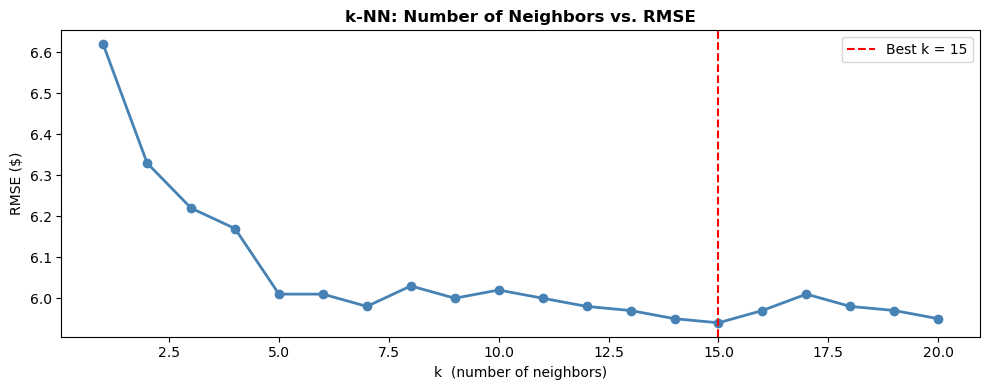

Best k = 15  |  CV-RMSE = $5.94


In [81]:
def find_best_k(X_train, y_train, k_range=range(1, 21)):
    """
    We use sklearn's built-in GridSearchCV to test every k from 1 to 20 and pick the one with the lowest RMSE.
    """
    param_grid = {"n_neighbors": list(k_range)}
    grid_search = GridSearchCV(KNeighborsRegressor(), param_grid,
                               cv=5, scoring="neg_mean_squared_error")
    grid_search.fit(X_train, y_train)

    ks = list(k_range)
    rmse_scores = np.sqrt(-grid_search.cv_results_["mean_test_score"]).round(2)
    best_k = grid_search.best_params_["n_neighbors"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ks, rmse_scores, marker="o", color="steelblue", linewidth=2)
    ax.axvline(best_k, color="red", linestyle="--", linewidth=1.5,
               label=f"Best k = {best_k}")
    ax.set_title("k-NN: Number of Neighbors vs. RMSE", fontweight="bold")
    ax.set_xlabel("k  (number of neighbors)")
    ax.set_ylabel("RMSE ($)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("knn_elbow.png", dpi=150)
    plt.show()

    print(f"Best k = {best_k}  |  CV-RMSE = ${rmse_scores[best_k - 1]:.2f}")
    return best_k

best_k = find_best_k(X_train_sc, y_train)

In [82]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Computes RMSE and R^2 score.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": model_name, "RMSE ($)": round(rmse, 2), "R² Score": round(r2, 4)}

In [83]:
def run_baseline_models(X_train, X_test, y_train, y_test, best_k):
    """
    We train a Linear Regression and k-NN model on the training set and evaluate both on the test set.
    """
    results = []

    # linear regression (expected to perform bad)
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    results.append(evaluate_model(y_test, lr.predict(X_test), "Linear Regression"))

    # k-NN with the best k chosen above
    knn = KNeighborsRegressor(n_neighbors=best_k)
    knn.fit(X_train, y_train)
    results.append(evaluate_model(y_test, knn.predict(X_test), f"k-NN (k={best_k})"))

    results_df = pd.DataFrame(results)
    display(results_df)
    print("\nRMSE = average dollar error per prediction")
    print("R^2 = 1.0 is perfect, 0.0 is just guessing the mean price")

    return lr, knn, results_df


lr_model, knn_model, baseline_results = run_baseline_models(
    X_train_sc, X_test_sc, y_train, y_test, best_k)

,Model,RMSE ($),R² Score
0,Linear Regression,5.43,0.0813
1,k-NN (k=15),5.55,0.0397



RMSE = average dollar error per prediction
R^2 = 1.0 is perfect, 0.0 is just guessing the mean price


In [84]:
baseline_results.to_csv("baseline_results.csv", index=False)
print("Saved → baseline_results.csv")

Saved → baseline_results.csv
